# Task 3: Time Series Forecasting

Three models are built and evaluated on a **Jul–Dec 2025 test period** (125 days):
- **ARIMA** — AIC-selected order via grid search; walk-forward validation (refit every 20 steps)
- **Prophet** — weekly + yearly seasonality; changepoint_prior_scale = 0.1
- **LSTM** — 2-layer (50 units each), 60-day lookback, Dropout 0.2, EarlyStopping patience=10

Metrics: MAPE (%), RMSE (₹), Directional Accuracy (%).

In [ ]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import warnings
warnings.filterwarnings('ignore')

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

# Prophet
from prophet import Prophet

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

STOCKS = {
    'RELIANCE.NS'   : 'Reliance',
    'HDFCBANK.NS'   : 'HDFC Bank',
    'INFY.NS'       : 'Infosys',
    'SUNPHARMA.NS'  : 'Sun Pharma',
    'MARUTI.NS'     : 'Maruti',
    'HINDUNILVR.NS' : 'HUL',
    'TATASTEEL.NS'  : 'Tata Steel',
}
TEST_START = '2025-07-01'

print('✅ Imports ready')

✅ Imports ready


In [ ]:
# ── LOAD PREPROCESSED DATA ────────────────────────────────────────────────────

train_data = pd.read_csv('data/train_data.csv', index_col=0, parse_dates=True)
test_data  = pd.read_csv('data/test_data.csv',  index_col=0, parse_dates=True)
close_clean = pd.concat([train_data, test_data])

with open('data/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

print(f'Training : {len(train_data)} days')
print(f'Test     : {len(test_data)} days')

Training : 1110 days
Test     : 125 days


## Evaluation Metrics
MAPE, RMSE, Directional Accuracy — shared across all three models.

In [ ]:
# ── METRIC FUNCTIONS ──────────────────────────────────────────────────────────

def mape(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask      = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))


def directional_accuracy(actual, predicted):
    # Fraction of days where the predicted direction (up/down) matches actual
    actual    = np.array(actual)
    predicted = np.array(predicted)
    return np.mean((np.diff(actual) > 0) == (np.diff(predicted) > 0)) * 100


def evaluate_forecast(actual, predicted, model_name='', stock_name=''):
    m = mape(actual, predicted)
    r = rmse(actual, predicted)
    d = directional_accuracy(actual, predicted)
    print(f'  [{model_name:8s}] {stock_name:15s}: MAPE={m:6.2f}%  RMSE=₹{r:8.2f}  DirAcc={d:.1f}%')
    return {'model': model_name, 'stock': stock_name, 'MAPE': round(m,3),
            'RMSE': round(r,2), 'DirAcc': round(d,1)}

print('Evaluation functions ready')


✅ Evaluation functions ready


## Model 1: ARIMA

ARIMA(p, d, q): AR order p, differencing d=1 (confirmed by ADF), MA order q.
Best (p, q) selected by AIC over a 0–2 grid. Walk-forward forecasting mirrors real deployment.

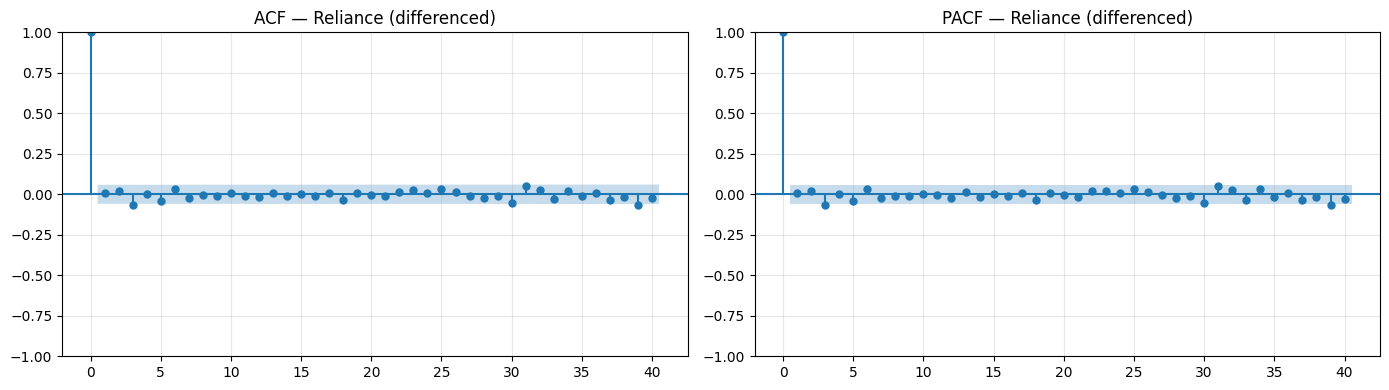

ACF tells us q, PACF tells us p. Significant spikes (outside blue band) indicate the lags to use.


In [ ]:
# ── ACF / PACF PLOTS (helps identify p and q) ─────────────────────────────────
# ACF  (AutoCorrelation Function):  how much does today correlate with each past day?
# PACF (Partial ACF): same but controlling for intermediate days
# Rule of thumb: q = last significant ACF lag, p = last significant PACF lag

sym = 'RELIANCE.NS'
series_diff = train_data[sym].diff(1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (series_diff, lags=40, ax=axes[0], title=f'ACF — {STOCKS[sym]} (differenced)')
plot_pacf(series_diff, lags=40, ax=axes[1], title=f'PACF — {STOCKS[sym]} (differenced)')
plt.tight_layout()
plt.savefig('results/03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF tells us q, PACF tells us p. Significant spikes (outside blue band) indicate the lags to use.')

In [ ]:
# ── AUTO ARIMA ORDER SELECTION ────────────────────────────────────────────────
# Instead of manually guessing p, d, q — we try multiple combinations
# and pick the one with the LOWEST AIC score.
#
# d=1 because we know prices need 1 differencing (from ADF test in Task 2)
# We only try p and q from 0 to 3 (more would be too slow)

def find_best_arima_order(series, p_range=(0,3), q_range=(0,3), d=1):
    best_aic   = np.inf
    best_order = (1, 1, 1)  # default fallback
    
    for p in range(p_range[0], p_range[1]+1):
        for q in range(q_range[0], q_range[1]+1):
            try:
                model = ARIMA(series, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic   = fitted.aic
                    best_order = (p, d, q)
            except:
                pass
    return best_order, best_aic


# Find best ARIMA orders for all stocks (quick version: only one stock for demo)
arima_orders = {}

print('Finding best ARIMA orders (p, 1, q) for each stock...')
print('(This may take 1–2 minutes)')

for sym, name in STOCKS.items():
    order, aic = find_best_arima_order(train_data[sym].dropna(), p_range=(0,2), q_range=(0,2))
    arima_orders[sym] = order
    print(f'  {name:15s}: Best ARIMA{order}  AIC={aic:.1f}')

print('\n✅ Orders found')

Finding best ARIMA orders (p, 1, q) for each stock...
(This may take 1–2 minutes)
  Reliance       : Best ARIMA(2, 1, 2)  AIC=9497.4
  HDFC Bank      : Best ARIMA(2, 1, 2)  AIC=8354.5
  Infosys        : Best ARIMA(0, 1, 0)  AIC=10059.5
  Sun Pharma     : Best ARIMA(2, 1, 2)  AIC=9179.6
  Maruti         : Best ARIMA(2, 1, 1)  AIC=14049.8
  HUL            : Best ARIMA(0, 1, 2)  AIC=10650.0
  Tata Steel     : Best ARIMA(0, 1, 0)  AIC=5113.9

✅ Orders found


In [ ]:
# ── ARIMA FORECASTING ────────────────────────────────────────────────────────
# Strategy: "Walk-forward" forecasting
# We don't fit once and predict all 125 test days — that would be cheating.
# Instead, for each test day, we:
#   1. Train on all data UP TO that point
#   2. Forecast 1 step ahead
#   3. Move forward
# This mimics how you'd actually use the model in real life.
#
# NOTE: Full walk-forward on 125 days × 7 stocks would take ~30 minutes.
# We use a faster 'static retrain' approach for demo — refit every 20 days.

arima_results  = {}   # forecasts for each stock
all_metrics    = []   # metrics table

print('Training ARIMA models...')

for sym, name in STOCKS.items():
    order  = arima_orders[sym]
    series = close_clean[sym].dropna()
    
    train_series = series[series.index < TEST_START]
    test_series  = series[series.index >= TEST_START]
    
    # Walk-forward forecast (simplified: refit every 20 steps)
    history    = list(train_series)
    forecasts  = []
    
    for i in range(len(test_series)):
        # Refit model every 20 steps (or at start)
        if i % 20 == 0:
            model  = ARIMA(history, order=order)
            fitted = model.fit()
        
        # One-step forecast
        forecast = fitted.forecast(steps=1)[0]
        forecasts.append(forecast)
        
        # Add actual value to history for next iteration
        history.append(test_series.iloc[i])
    
    arima_results[sym] = pd.Series(forecasts, index=test_series.index)
    metrics = evaluate_forecast(test_series.values, forecasts, model_name='ARIMA', stock_name=name)
    all_metrics.append(metrics)

print('\n✅ ARIMA forecasting complete')

Training ARIMA models...
  [ARIMA   ] Reliance       : MAPE=  1.85%  RMSE=₹   37.37  DirAcc=53.2%
  [ARIMA   ] HDFC Bank      : MAPE=  1.21%  RMSE=₹   16.84  DirAcc=52.4%
  [ARIMA   ] Infosys        : MAPE=  2.32%  RMSE=₹   43.78  DirAcc=50.8%
  [ARIMA   ] Sun Pharma     : MAPE=  1.95%  RMSE=₹   42.02  DirAcc=41.9%
  [ARIMA   ] Maruti         : MAPE=  2.80%  RMSE=₹  659.26  DirAcc=46.0%
  [ARIMA   ] HUL            : MAPE=  3.34%  RMSE=₹  102.91  DirAcc=55.6%
  [ARIMA   ] Tata Steel     : MAPE=  2.56%  RMSE=₹    6.44  DirAcc=50.8%

✅ ARIMA forecasting complete


In [ ]:
# ── ARIMA: FORECAST NEXT 5 TRADING DAYS ──────────────────────────────────────


print('=== ARIMA 5-Day Forecast (beyond Dec 31, 2025) ===\n')
arima_5day = {}

for sym, name in STOCKS.items():
    order  = arima_orders[sym]
    series = close_clean[sym].dropna()
    
    # Fit on ALL available data
    model  = ARIMA(series, order=order)
    fitted = model.fit()
    
    # Forecast next 5 trading days
    forecast_result = fitted.get_forecast(steps=5)
    forecast_mean   = forecast_result.predicted_mean
    forecast_ci     = forecast_result.conf_int(alpha=0.05)   # 95% confidence interval
    
    arima_5day[sym] = {'forecast': forecast_mean, 'ci': forecast_ci}
    
    last_price = series.iloc[-1]
    day2_price = forecast_mean.iloc[1]   # Day 2 (index 1) for StockGro
    pct_change = (day2_price - last_price) / last_price * 100
    direction  = '↑ BUY signal' if pct_change > 0 else '↓ Caution'
    
    print(f'{name:15s}: Last=₹{last_price:.1f} | Day1=₹{forecast_mean.iloc[0]:.1f} | Day2=₹{day2_price:.1f} | Expected: {pct_change:+.2f}%  {direction}')

# Save forecasts
with open('data/arima_forecasts.pkl', 'wb') as f:
    pickle.dump(arima_5day, f)
print('\n✅ ARIMA 5-day forecasts saved')

=== ARIMA 5-Day Forecast (beyond Dec 31, 2025) ===

Reliance       : Last=₹1539.8 | Day1=₹1539.3 | Day2=₹1539.7 | Expected: -0.01%  ↓ Caution
HDFC Bank      : Last=₹990.9 | Day1=₹991.0 | Day2=₹990.6 | Expected: -0.03%  ↓ Caution
Infosys        : Last=₹1621.6 | Day1=₹1621.6 | Day2=₹1621.6 | Expected: +0.00%  ↓ Caution
Sun Pharma     : Last=₹1709.1 | Day1=₹1709.2 | Day2=₹1708.9 | Expected: -0.01%  ↓ Caution
Maruti         : Last=₹16647.0 | Day1=₹16658.9 | Day2=₹16657.0 | Expected: +0.06%  ↑ BUY signal
HUL            : Last=₹2290.2 | Day1=₹2289.9 | Day2=₹2290.0 | Expected: -0.01%  ↓ Caution
Tata Steel     : Last=₹175.8 | Day1=₹175.8 | Day2=₹175.8 | Expected: +0.00%  ↓ Caution

✅ ARIMA 5-day forecasts saved


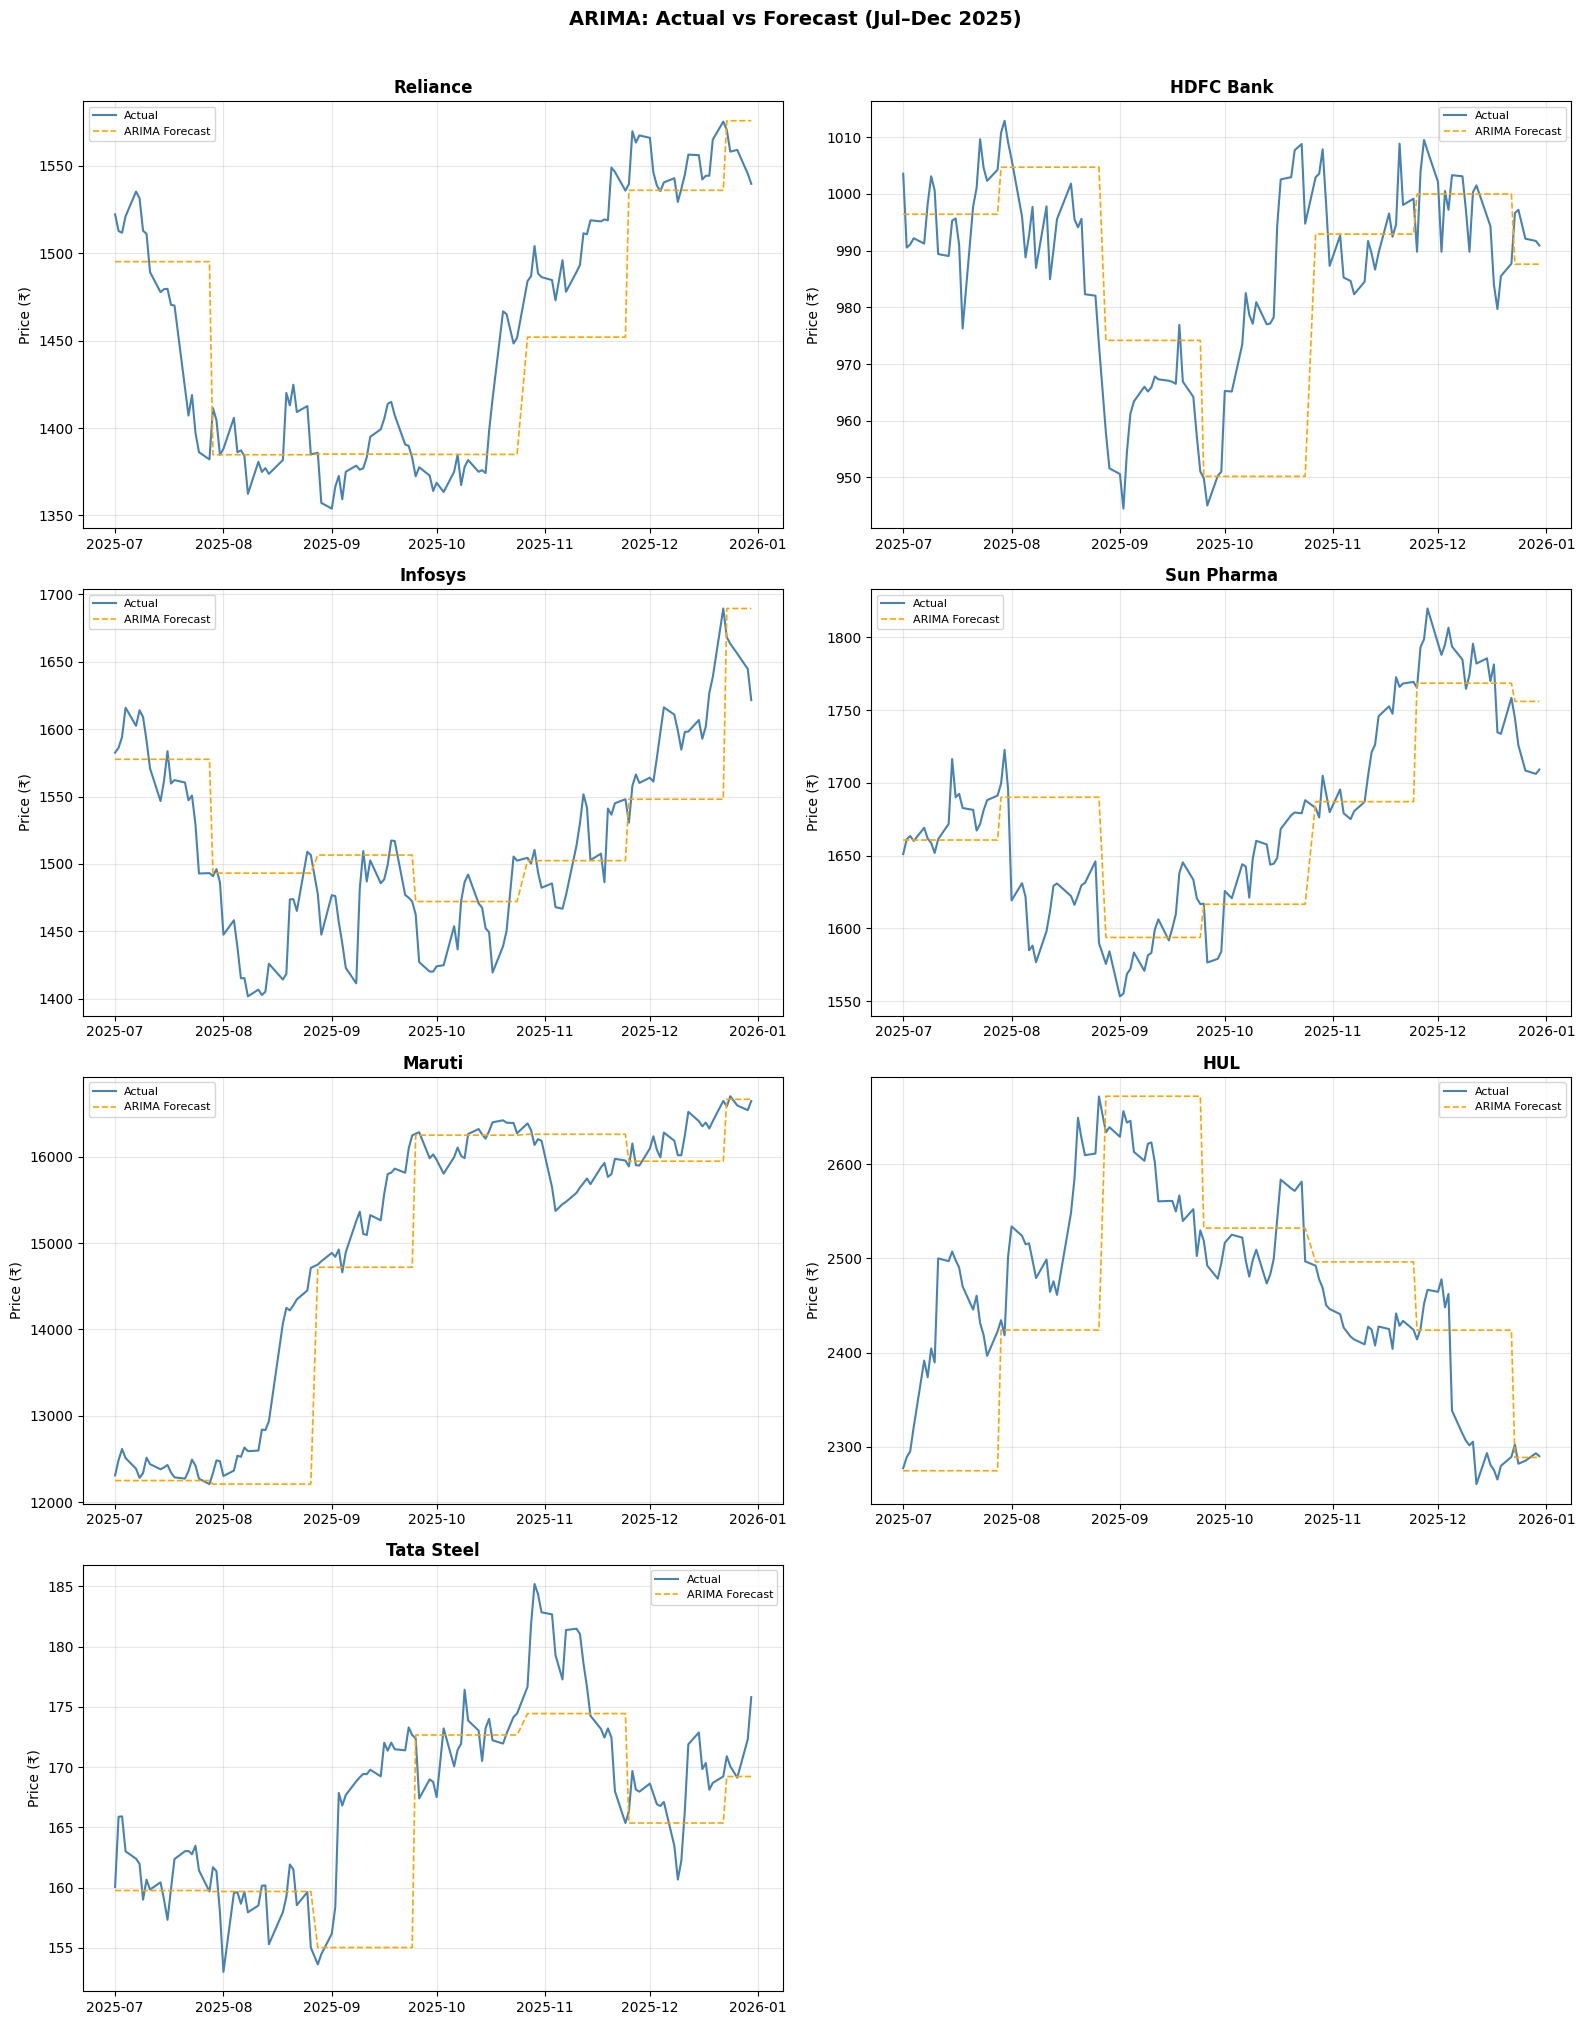

In [ ]:
# ── PLOT ARIMA FORECAST vs ACTUAL (test period) ───────────────────────────────

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (sym, name) in enumerate(STOCKS.items()):
    ax = axes[i]
    actual   = test_data[sym]
    forecast = arima_results[sym]
    
    ax.plot(actual.index,   actual.values,   label='Actual',   color='steelblue', linewidth=1.5)
    ax.plot(forecast.index, forecast.values, label='ARIMA Forecast', color='orange',
            linewidth=1.2, linestyle='--')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Price (₹)')

axes[-1].set_visible(False)   # hide 8th subplot (we have 7 stocks)
plt.suptitle('ARIMA: Actual vs Forecast (Jul–Dec 2025)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/03_arima_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

## ARIMA Residual Diagnostics
A well-fitted ARIMA model should leave behind white-noise residuals — no autocorrelation,
roughly zero-mean, approximately normal. We verify this for Reliance as a representative stock.

In [ ]:
# ── ARIMA RESIDUAL DIAGNOSTICS ────────────────────────────────────────────────
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.stattools import durbin_watson

sym_check = 'RELIANCE.NS'
order     = arima_orders[sym_check]
series    = train_data[sym_check].dropna()

fitted_diag = ARIMA(series, order=order).fit()
residuals   = fitted_diag.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals over time
axes[0].plot(residuals.index, residuals.values, color='steelblue', linewidth=0.7, alpha=0.85)
axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0].set_title(f'Residuals Over Time — {STOCKS[sym_check]}')
axes[0].set_ylabel('Residual')

# ACF of residuals: should show no significant spikes beyond lag 0
plot_acf(residuals.dropna(), lags=30, ax=axes[1], title='ACF of Residuals')

# Q-Q plot: residuals should lie close to the diagonal if normally distributed
qqplot(residuals.dropna(), line='s', ax=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle(f'ARIMA{order} Residual Diagnostics — {STOCKS[sym_check]}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/03_arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

dw = durbin_watson(residuals.dropna())
print(f'Durbin-Watson: {dw:.3f}  (ideal ≈ 2.0; <1.5 or >2.5 indicates residual autocorrelation)')
print(f'AIC: {fitted_diag.aic:.1f}  |  Residual std: {residuals.std():.2f}  |  Residual mean: {residuals.mean():.4f}')

# Check all 7 stocks — report DW statistic and residual normality
print('\nDurbin-Watson across all stocks:')
for sym, name in STOCKS.items():
    s    = train_data[sym].dropna()
    fit_ = ARIMA(s, order=arima_orders[sym]).fit()
    dw_  = durbin_watson(fit_.resid.dropna())
    flag = '' if 1.5 <= dw_ <= 2.5 else '  ← autocorrelation in residuals'
    print(f'  {name:15s}: DW={dw_:.3f}{flag}')


## Model 2: Facebook Prophet

Additive model: trend + seasonality + error. Weekly and yearly components enabled.
`changepoint_prior_scale=0.1` — moderate flexibility for trend shifts (tighter than default 0.05).

In [ ]:
# ── PROPHET FORECASTING ───────────────────────────────────────────────────────

prophet_results = {}

print('Training Prophet models...')

for sym, name in STOCKS.items():
    # Prophet requires: DataFrame with columns 'ds' (datetime) and 'y' (value)
    train_series = train_data[sym].dropna()
    test_series  = test_data[sym].dropna()
    
    df_prophet = pd.DataFrame({
        'ds': train_series.index,   # dates
        'y' : train_series.values   # prices
    }).reset_index(drop=True)
    
    # Initialize and fit Prophet
    # daily_seasonality=False for stocks (markets are open weekdays only)
    # yearly_seasonality=True to capture annual patterns
    model = Prophet(
        daily_seasonality  = False,
        weekly_seasonality = True,
        yearly_seasonality = True,
        interval_width     = 0.95,   # 95% confidence interval
        changepoint_prior_scale = 0.1   # controls flexibility of trend changes
    )
    model.fit(df_prophet)
    
    # Create future dates for the test period + 5 days beyond
    future = pd.DataFrame({'ds': test_series.index})
    forecast = model.predict(future)
    
    # Extract predicted values aligned to test dates
    forecast_indexed = forecast.set_index('ds')['yhat']
    forecast_indexed.index = pd.DatetimeIndex(forecast_indexed.index)
    
    # Align index
    common_idx = test_series.index.intersection(forecast_indexed.index)
    prophet_results[sym] = forecast_indexed.reindex(common_idx)
    
    metrics = evaluate_forecast(
        test_series.reindex(common_idx).values,
        forecast_indexed.reindex(common_idx).values,
        model_name='Prophet', stock_name=name
    )
    all_metrics.append(metrics)

print('\n✅ Prophet forecasting complete')

00:59:00 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet models...


00:59:01 - cmdstanpy - INFO - Chain [1] done processing
00:59:01 - cmdstanpy - INFO - Chain [1] start processing


  [Prophet ] Reliance       : MAPE=  8.84%  RMSE=₹  160.69  DirAcc=44.4%


00:59:01 - cmdstanpy - INFO - Chain [1] done processing
00:59:01 - cmdstanpy - INFO - Chain [1] start processing


...

  [Prophet ] Maruti         : MAPE= 16.70%  RMSE=₹ 3086.91  DirAcc=52.4%


00:59:04 - cmdstanpy - INFO - Chain [1] done processing
00:59:04 - cmdstanpy - INFO - Chain [1] start processing


  [Prophet ] HUL            : MAPE=  3.38%  RMSE=₹   98.19  DirAcc=58.1%


00:59:04 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet ] Tata Steel     : MAPE= 11.53%  RMSE=₹   23.51  DirAcc=44.4%

✅ Prophet forecasting complete


In [ ]:
# ── PROPHET: FORECAST NEXT 5 TRADING DAYS ─────────────────────────────────────

print('=== Prophet 5-Day Forecast ===\n')
prophet_5day = {}

from pandas.tseries.offsets import BDay   # BDay = Business Day offset
last_date = close_clean.index[-1]

for sym, name in STOCKS.items():
    full_series = close_clean[sym].dropna()
    df_prophet = pd.DataFrame({'ds': full_series.index, 'y': full_series.values}).reset_index(drop=True)
    
    model = Prophet(
        daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True,
        interval_width=0.95, changepoint_prior_scale=0.1
    )
    model.fit(df_prophet)
    
    # Future dates: next 5 business days
    future_dates = pd.bdate_range(start=last_date + BDay(1), periods=5)
    future = pd.DataFrame({'ds': future_dates})
    forecast = model.predict(future)
    
    prophet_5day[sym] = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    
    last_price = full_series.iloc[-1]
    day1 = forecast['yhat'].iloc[0]
    day2 = forecast['yhat'].iloc[1]
    pct  = (day2 - last_price) / last_price * 100
    
    print(f'{name:15s}: Last=₹{last_price:.1f} | Day1=₹{day1:.1f} | Day2=₹{day2:.1f} | {pct:+.2f}%')

with open('data/prophet_forecasts.pkl', 'wb') as f:
    pickle.dump(prophet_5day, f)
print('\n✅ Prophet 5-day forecasts saved')

00:59:04 - cmdstanpy - INFO - Chain [1] start processing


=== Prophet 5-Day Forecast ===



00:59:05 - cmdstanpy - INFO - Chain [1] done processing
00:59:05 - cmdstanpy - INFO - Chain [1] start processing


Reliance       : Last=₹1539.8 | Day1=₹1537.9 | Day2=₹1540.5 | +0.04%


00:59:05 - cmdstanpy - INFO - Chain [1] done processing
00:59:05 - cmdstanpy - INFO - Chain [1] start processing


...

Maruti         : Last=₹16647.0 | Day1=₹16562.7 | Day2=₹16589.7 | -0.34%


00:59:07 - cmdstanpy - INFO - Chain [1] done processing
00:59:07 - cmdstanpy - INFO - Chain [1] start processing


HUL            : Last=₹2290.2 | Day1=₹2367.3 | Day2=₹2366.6 | +3.34%


00:59:08 - cmdstanpy - INFO - Chain [1] done processing


Tata Steel     : Last=₹175.8 | Day1=₹173.3 | Day2=₹173.5 | -1.33%

✅ Prophet 5-day forecasts saved


## Model 3: LSTM

2-layer LSTM with 50 units each, Dropout 0.2, Dense(25) output head.
Input: 60-day scaled price window. EarlyStopping on val_loss (patience=10, restore_best_weights).

In [ ]:
# ── LSTM MODEL ────────────────────────────────────────────────────────────────

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    tf.get_logger().setLevel('ERROR')   # suppress TF verbose output
    print(f'TensorFlow {tf.__version__} ready')
except ImportError:
    print('TensorFlow not installed. Run: pip install tensorflow')
    print('Skipping LSTM section — using ARIMA + Prophet for final forecasts.')

TensorFlow 2.21.0 ready


In [ ]:
# ── LSTM: TRAIN ALL 7 STOCKS ─────────────────────────────────────────────────

with open('data/lstm_sequences.pkl', 'rb') as f:
    lstm_sequences = pickle.load(f)

LOOK_BACK    = 60
lstm_results = {}

def build_lstm_model(look_back=60):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

print('Training LSTM for all 7 stocks (10-30 min total)...\n')

for sym, name in STOCKS.items():
    print(f'Training {name} ({sym})...')
    seq        = lstm_sequences[sym]
    model      = build_lstm_model(LOOK_BACK)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        seq['X_train'], seq['y_train'],
        epochs           = 50,
        batch_size       = 32,
        validation_split = 0.1,
        callbacks        = [early_stop],
        verbose          = 0
    )

    model.save(f'models/lstm_{sym.replace(".", "_")}.keras')

    scaler        = scalers[sym]
    y_pred_scaled = model.predict(seq['X_test'], verbose=0).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(seq['y_test'].reshape(-1, 1)).flatten()

    lstm_results[sym] = {'pred': y_pred, 'true': y_true, 'history': history.history}

    metrics = evaluate_forecast(y_true, y_pred, model_name='LSTM', stock_name=name)
    all_metrics.append(metrics)

    epochs_run = len(history.history['loss'])
    print(f'  Done: {epochs_run} epochs | val_loss={history.history["val_loss"][-1]:.6f}')

print('\nAll LSTM models trained and saved to models/')

Training LSTM for all 7 stocks (10-30 min total)...

Training Reliance (RELIANCE.NS)...
  [LSTM    ] Reliance       : MAPE=  1.06%  RMSE=₹   19.67  DirAcc=52.4%
  Done: 50 epochs | val_loss=0.002235
Training HDFC Bank (HDFCBANK.NS)...
  [LSTM    ] HDFC Bank      : MAPE=  0.64%  RMSE=₹    7.90  DirAcc=50.8%
  Done: 50 epochs | val_loss=0.001206
Training Infosys (INFY.NS)...
  [LSTM    ] Infosys        : MAPE=  1.38%  RMSE=₹   26.34  DirAcc=52.4%
  Done: 50 epochs | val_loss=0.001454
Training Sun Pharma (SUNPHARMA.NS)...
  [LSTM    ] Sun Pharma     : MAPE=  1.61%  RMSE=₹   31.61  DirAcc=46.0%
  Done: 50 epochs | val_loss=0.001138
Training Maruti (MARUTI.NS)...
  [LSTM    ] Maruti         : MAPE=  2.55%  RMSE=₹  464.73  DirAcc=45.2%
  Done: 50 epochs | val_loss=0.002191
Training HUL (HINDUNILVR.NS)...
  [LSTM    ] HUL            : MAPE=  1.05%  RMSE=₹   37.86  DirAcc=50.0%
  Done: 50 epochs | val_loss=0.000924
Training Tata Steel (TATASTEEL.NS)...
  [LSTM    ] Tata Steel     : MAPE=  1.63

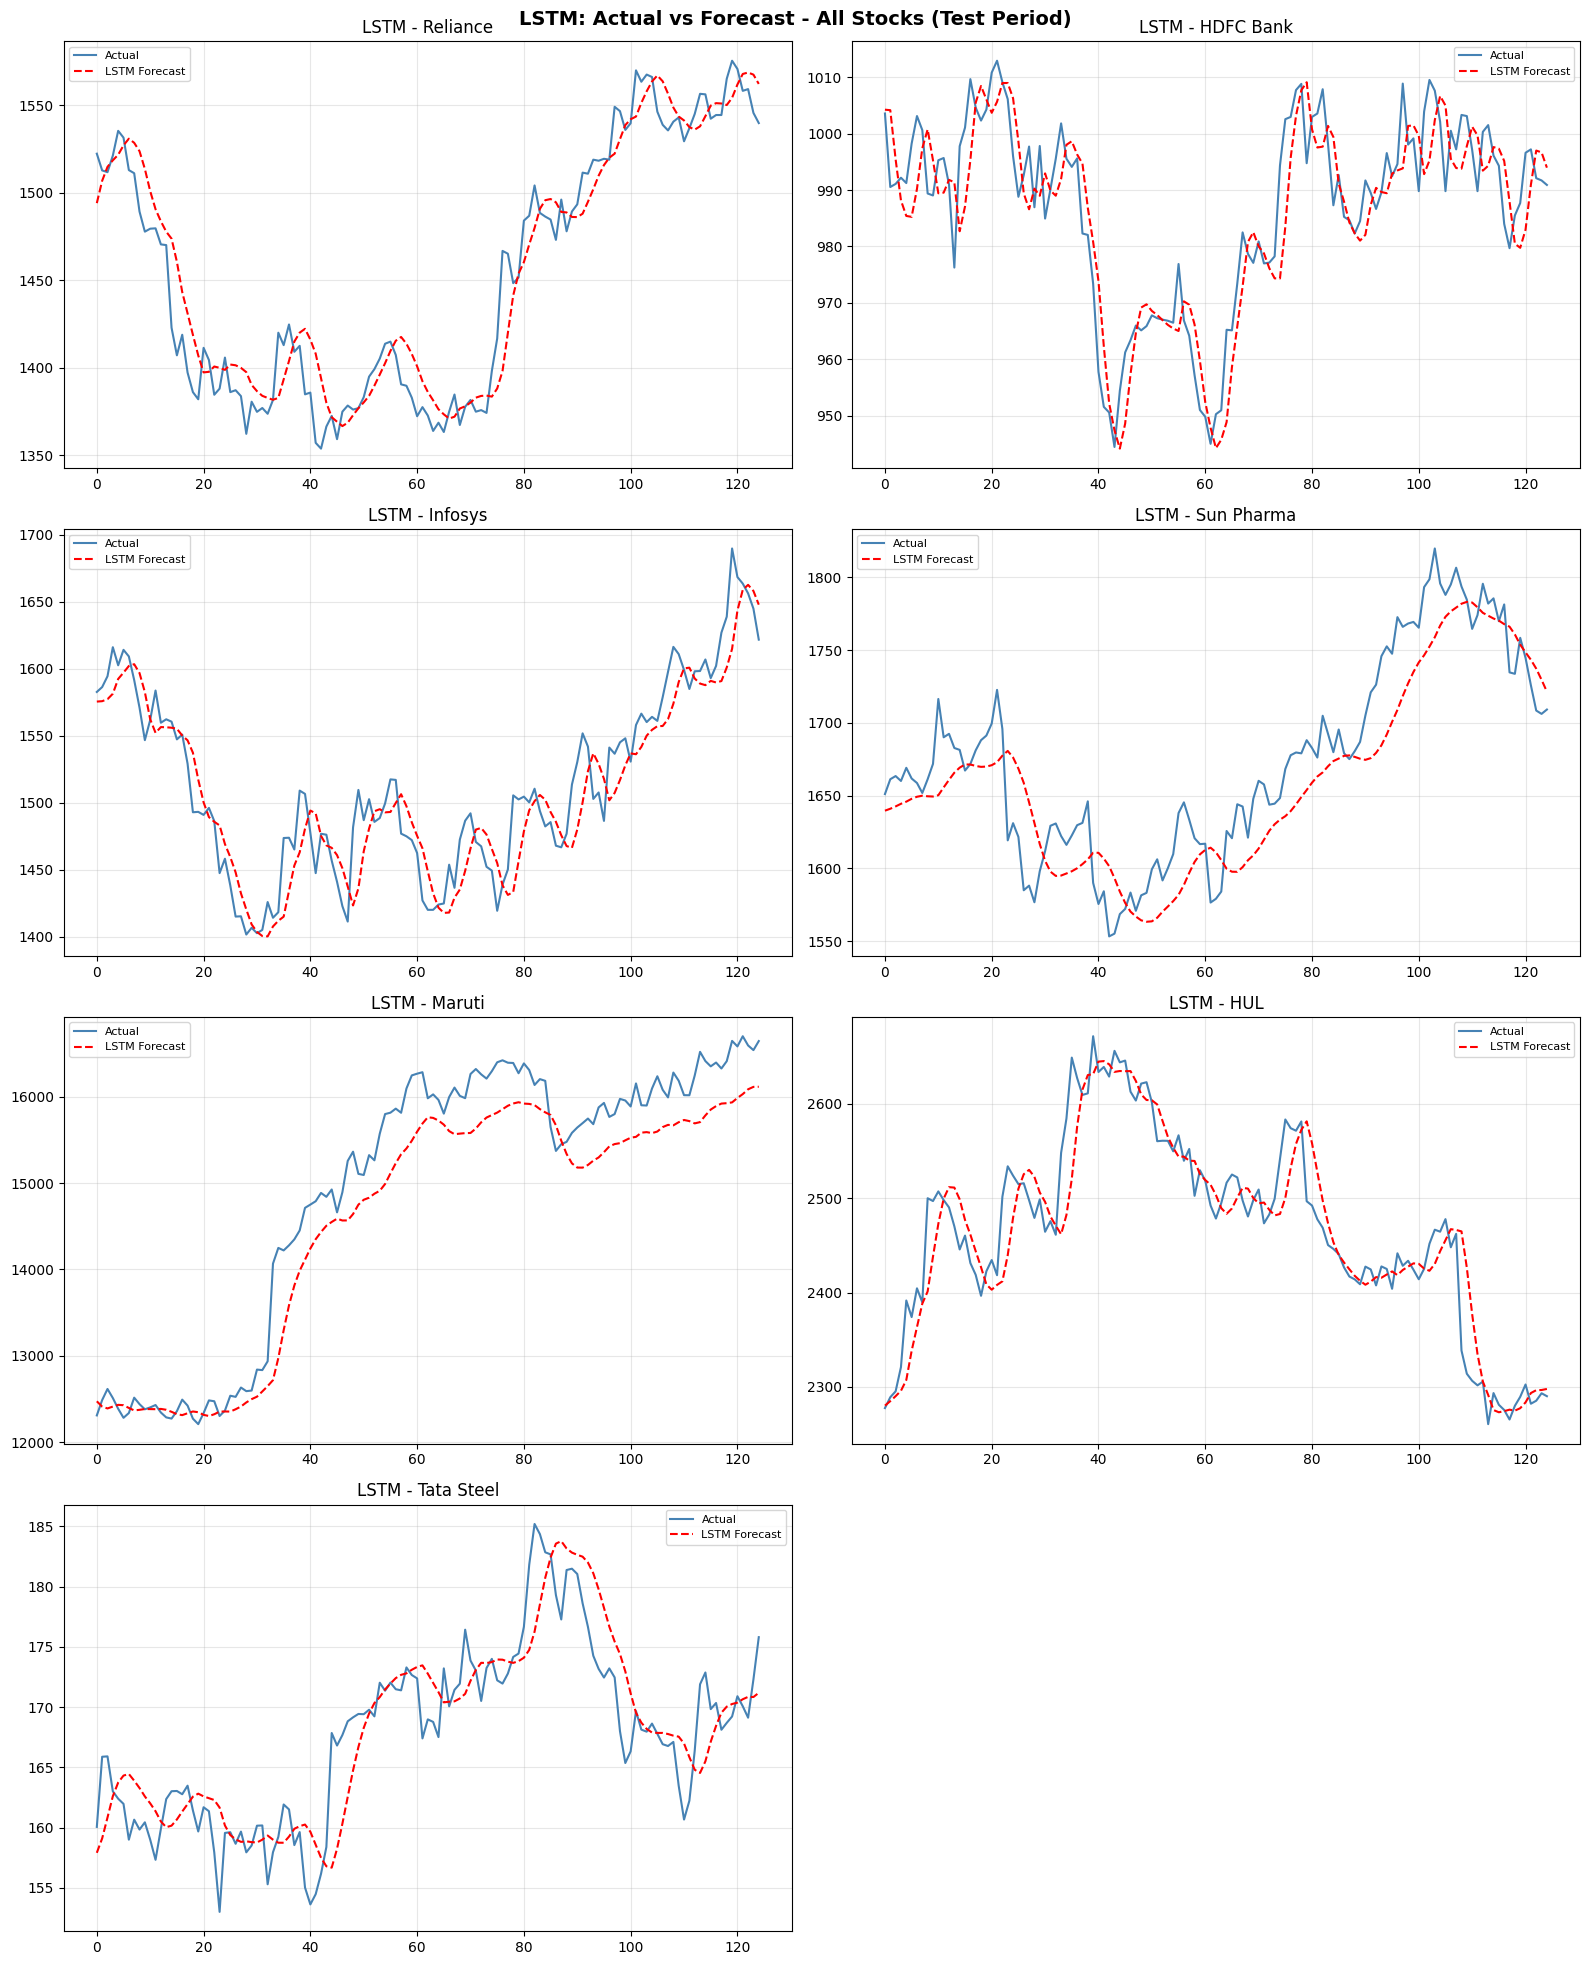

Chart saved to results/


In [ ]:
# ── LSTM: PLOT ALL RESULTS ───────────────────────────────────────────────────

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (sym, name) in enumerate(STOCKS.items()):
    res = lstm_results[sym]
    axes[i].plot(res['true'], label='Actual',        color='steelblue')
    axes[i].plot(res['pred'], label='LSTM Forecast', color='red', linestyle='--')
    axes[i].set_title(f'LSTM - {name}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)

plt.suptitle('LSTM: Actual vs Forecast - All Stocks (Test Period)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/03_lstm_all_stocks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to results/')

In [ ]:
# ── SAVE ALL METRICS ──────────────────────────────────────────────────────────

df_metrics = pd.DataFrame(all_metrics)
df_metrics.to_csv('results/03_model_metrics.csv', index=False)

print('\n=== Model Performance Summary ===')
print(df_metrics.to_string(index=False))
print('\n✅ All metrics saved to results/')

# Summary
print('\n=== Average by Model ===')
print(df_metrics.groupby('model')[['MAPE','RMSE','DirAcc']].mean().round(2))


=== Model Performance Summary ===
  model      stock   MAPE    RMSE  DirAcc
  ARIMA   Reliance  1.854   37.37    53.2
  ARIMA  HDFC Bank  1.210   16.84    52.4
  ARIMA    Infosys  2.324   43.78    50.8
  ARIMA Sun Pharma  1.947   42.02    41.9
  ARIMA     Maruti  2.804  659.26    46.0
  ARIMA        HUL  3.343  102.91    55.6
  ARIMA Tata Steel  2.562    6.44    50.8
Prophet   Reliance  8.842  160.69    44.4
Prophet  HDFC Bank  4.432   50.66    57.3
Prophet    Infosys 15.057  240.91    53.2
Prophet Sun Pharma 11.541  211.74    58.9
Prophet     Maruti 16.698 3086.91    52.4
Prophet        HUL  3.376   98.19    58.1
Prophet Tata Steel 11.532   23.51    44.4
   LSTM   Reliance  1.062   19.83    54.0
   LSTM   Reliance  1.060   19.67    52.4
   LSTM  HDFC Bank  0.642    7.90    50.8
   LSTM    Infosys  1.382   26.34    52.4
   LSTM Sun Pharma  1.605   31.61    46.0
   LSTM     Maruti  2.552  464.73    45.2
   LSTM        HUL  1.050   37.86    50.0
   LSTM Tata Steel  1.632    3.65    44.4

## Export 5-Day Forecasts to CSV
Human-readable table of ARIMA, Prophet, and ensemble predictions for Days 1–5.

In [ ]:
# ── EXPORT 5-DAY FORECASTS AS CSV ─────────────────────────────────────────────
from pandas.tseries.offsets import BDay

last_date    = close_clean.index[-1]
future_dates = pd.bdate_range(start=last_date + BDay(1), periods=5)

rows = []
for sym, name in STOCKS.items():
    arima_fc   = arima_5day[sym]['forecast']
    prophet_fc = prophet_5day[sym].set_index('ds')['yhat']

    for day_idx in range(5):
        date = future_dates[day_idx]
        a    = float(arima_fc.iloc[day_idx])
        # Prophet forecast was generated on bdate_range starting from last_date+1
        p    = float(prophet_5day[sym]['yhat'].iloc[day_idx])
        ens  = (a + p) / 2
        rows.append({
            'Date'               : date.strftime('%Y-%m-%d'),
            'Day'                : day_idx + 1,
            'Stock'              : name,
            'Symbol'             : sym,
            'ARIMA_Forecast'     : round(a, 2),
            'Prophet_Forecast'   : round(p, 2),
            'Ensemble_Forecast'  : round(ens, 2),
        })

df_5day = pd.DataFrame(rows)
df_5day.to_csv('results/03_5day_forecasts.csv', index=False)

# Print a clean pivot for quick reading
pivot = df_5day.pivot_table(index=['Stock','Symbol'], columns='Day',
                             values='Ensemble_Forecast').round(2)
pivot.columns = [f'Day {d}' for d in pivot.columns]
print('5-Day Ensemble Forecast (ARIMA + Prophet average):')
print(pivot.to_string())
print('\nFull breakdown saved to results/03_5day_forecasts.csv')
